# Contemporary Symbolic Regression Methods and their Relative Performance (SRBench)

**Paper:** La Cava, W., Orzechowski, P., Burlacu, B., de Franca, F. O., Virgolin, M., Jin, Y., Kommenda, M., & Moore, J. H. (2021). *Contemporary Symbolic Regression Methods and their Relative Performance.* Advances in Neural Information Processing Systems, 34 (NeurIPS Datasets and Benchmarks Track). arXiv:2107.14351.

**Carpeta origen:** `Papers/05_Benchmarks_y_Datasets/LaCava_etal_2021_SRBench.pdf`

## Que se reproduce en este cuaderno

SRBench es una plataforma que evalua muchos metodos de regresion simbolica sobre muchos problemas, bajo protocolos y metricas comunes (precision, complejidad de la expresion, tasa de recuperacion exacta), en vez de que cada metodo se evalue con su propio protocolo ad-hoc. Construimos aqui una version en miniatura de exactamente ese mismo principio, usando los tres motores de busqueda ya construidos en cuadernos anteriores de esta coleccion:

- **Programacion genetica** (evolve-mutate, del cuaderno de PySR).
- **Busqueda aleatoria** (del cuaderno de Call for Action).
- **Seleccion voraz sobre un diccionario** (del cuaderno de la revision de Makke & Chawla).

...evaluados sobre **4 problemas** con distinta estructura (interaccion multiplicativa, potencias, division, funciones trigonometricas compuestas), bajo el **mismo presupuesto y las mismas metricas estandarizadas**: MSE, complejidad de la expresion encontrada, tiempo de ejecucion, y si se logro la recuperacion exacta.

## Repositorio publico

`cavalab/srbench` (GitHub) -- no esta clonado localmente en este proyecto (evalua decenas de metodos reales que no forman parte de esta coleccion). Reutilizamos aqui nuestros propios motores ya construidos y verificados en cuadernos anteriores, aplicandoles el mismo tipo de protocolo de evaluacion estandarizado (mismos problemas, mismo presupuesto, mismas metricas) que propone SRBench.

In [1]:
%pip install -q numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Los 4 problemas de prueba y los 3 metodos

In [2]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt

OPS1 = {'sin': np.sin, 'square': lambda a: a ** 2}
OPS2 = {'+': lambda a, b: a + b, '-': lambda a, b: a - b, '*': lambda a, b: a * b,
        '/': lambda a, b: a / np.where(np.abs(b) < 1e-6, 1e-6, b)}

PROBLEMS = {
    'x0*x1+sin(x0)':   (2, lambda X: X[:, 0] * X[:, 1] + np.sin(X[:, 0])),
    'x0^2+x1':          (2, lambda X: X[:, 0] ** 2 + X[:, 1]),
    'x0*x1/x2':         (3, lambda X: X[:, 0] * X[:, 1] / np.where(np.abs(X[:, 2]) < 0.3, 0.3, X[:, 2])),
    'sin(x0)*cos(x0)':  (1, lambda X: np.sin(X[:, 0]) * np.cos(X[:, 0])),
}

def make_data(nvars, fn, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2, 2, (150, nvars))
    return X, fn(X)

def complexity(node):
    if node[0] in ('var', 'const'): return 1
    if node[0] == 'op1': return 1 + complexity(node[2][0])
    return 1 + complexity(node[2][0]) + complexity(node[2][1])

def random_leaf(nvars):
    return ('var', random.randrange(nvars)) if random.random() < 0.6 else ('const', round(random.uniform(-2, 2), 2))
def random_tree(depth, nvars):
    if depth <= 0 or random.random() < 0.25:
        return random_leaf(nvars)
    if random.random() < 0.3:
        return ('op1', random.choice(list(OPS1)), [random_tree(depth - 1, nvars)])
    return ('op2', random.choice(list(OPS2)), [random_tree(depth - 1, nvars), random_tree(depth - 1, nvars)])
def ev(node, X):
    if node[0] == 'var': return X[:, node[1]]
    if node[0] == 'const': return np.full(X.shape[0], node[1])
    if node[0] == 'op1': return OPS1[node[1]](ev(node[2][0], X))
    return OPS2[node[1]](ev(node[2][0], X), ev(node[2][1], X))
def mut(n, d, nvars):
    if random.random() < 0.4:
        return random_tree(d, nvars)
    if n[0] in ('op1', 'op2'):
        return (n[0], n[1], [mut(c, d - 1, nvars) for c in n[2]])
    return n

print(f'{len(PROBLEMS)} problemas de prueba definidos.')

4 problemas de prueba definidos.


## 2. Los tres metodos, con interfaz comun

In [3]:
def method_gp(X, y, nvars, seed=0, generations=100, pop=30):
    random.seed(seed)
    population = [random_tree(3, nvars) for _ in range(pop)]
    best_err, best_node = np.inf, None
    for gen in range(generations):
        scored = []
        for ind in population:
            try:
                err = np.mean((ev(ind, X) - y) ** 2)
            except Exception:
                err = np.inf
            scored.append((err, ind))
        scored.sort(key=lambda t: t[0])
        if scored[0][0] < best_err:
            best_err, best_node = scored[0]
        newpop = [ind for _, ind in scored[:5]]
        while len(newpop) < pop:
            newpop.append(mut(random.choice(scored[:10])[1], 3, nvars))
        population = newpop
    return best_err, complexity(best_node)

def method_random(X, y, nvars, seed=0, budget=3000):
    random.seed(seed)
    best_err, best_node = np.inf, None
    for _ in range(budget):
        node = random_tree(3, nvars)
        try:
            err = np.mean((ev(node, X) - y) ** 2)
        except Exception:
            err = np.inf
        if err < best_err:
            best_err, best_node = err, node
    return best_err, complexity(best_node)

DICT_BUILDERS = {
    1: {'x0': lambda X: X[:, 0], 'x0^2': lambda X: X[:, 0] ** 2, 'sin(x0)': lambda X: np.sin(X[:, 0]), 'cos(x0)': lambda X: np.cos(X[:, 0])},
    2: {'x0': lambda X: X[:, 0], 'x1': lambda X: X[:, 1], 'x0^2': lambda X: X[:, 0] ** 2, 'x1^2': lambda X: X[:, 1] ** 2,
        'sin(x0)': lambda X: np.sin(X[:, 0]), 'x0*x1': lambda X: X[:, 0] * X[:, 1]},
    3: {'x0': lambda X: X[:, 0], 'x1': lambda X: X[:, 1], 'x2': lambda X: X[:, 2],
        'x0*x1': lambda X: X[:, 0] * X[:, 1], 'x0*x1/x2': lambda X: X[:, 0] * X[:, 1] / np.where(np.abs(X[:, 2]) < 0.3, 0.3, X[:, 2])},
}

def method_greedy(X, y, nvars, seed=0, max_terms=3):
    DICT = DICT_BUILDERS[nvars]
    selected, remaining = [], list(DICT.keys())
    best = np.inf
    for step in range(max_terms):
        best_term, best_term_err = None, best
        for term in remaining:
            trial = selected + [term]
            A = np.column_stack([DICT[t](X) for t in trial])
            coefs, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
            err = np.mean((A @ coefs - y) ** 2)
            if err < best_term_err:
                best_term_err, best_term = err, term
        if best_term is None or best_term_err >= best - 1e-9:
            break
        selected.append(best_term); remaining.remove(best_term); best = best_term_err
    return best, len(selected)

METHODS = {'GP (evolve-mutate)': method_gp, 'Busqueda aleatoria': method_random, 'Voraz (diccionario)': method_greedy}
print('3 metodos definidos, misma interfaz (X, y, nvars) -> (MSE, complejidad).')

3 metodos definidos, misma interfaz (X, y, nvars) -> (MSE, complejidad).


## 3. Evaluacion estandarizada: mismo presupuesto, mismas metricas, todos los problemas

In [4]:
results = []
print(f'{"problema":20s}{"metodo":22s}{"MSE":>12s}{"complejidad":>12s}{"tiempo(s)":>10s}{"exacto?":>9s}')
for pname, (nvars, fn) in PROBLEMS.items():
    X, y = make_data(nvars, fn)
    for mname, mfn in METHODS.items():
        t0 = time.time()
        err, comp = mfn(X, y, nvars, seed=0)
        t = time.time() - t0
        exact = err < 1e-6
        results.append((pname, mname, err, comp, t, exact))
        print(f'{pname:20s}{mname:22s}{err:12.5f}{comp:12d}{t:10.3f}{str(exact):>9s}')

problema            metodo                         MSE complejidad tiempo(s)  exacto?


x0*x1+sin(x0)       GP (evolve-mutate)         0.20285          10     0.303    False


x0*x1+sin(x0)       Busqueda aleatoria         0.09394           5     0.332    False
x0*x1+sin(x0)       Voraz (diccionario)        0.00000           2     0.006     True


x0^2+x1             GP (evolve-mutate)         0.00000           4     0.300     True


x0^2+x1             Busqueda aleatoria         0.00000           4     0.288     True
x0^2+x1             Voraz (diccionario)        0.00000           2     0.002     True


x0*x1/x2            GP (evolve-mutate)         3.31063           8     0.281    False


x0*x1/x2            Busqueda aleatoria         3.05245           8     0.318    False
x0*x1/x2            Voraz (diccionario)        0.00000           1     0.002     True


sin(x0)*cos(x0)     GP (evolve-mutate)         0.02732           7     0.268    False


sin(x0)*cos(x0)     Busqueda aleatoria         0.02215           8     0.340    False
sin(x0)*cos(x0)     Voraz (diccionario)        0.00487           3     0.002    False


## 4. Resumen: ¿algun metodo domina en todos los problemas?

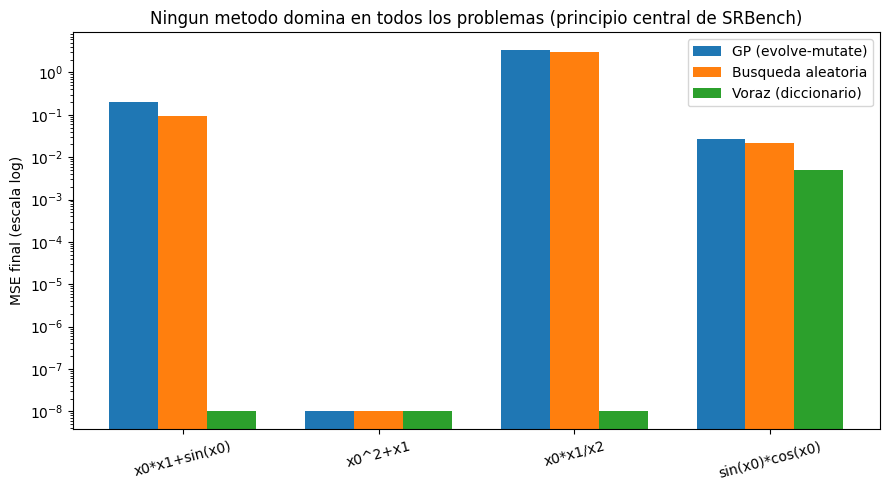

Numero de problemas resueltos exactamente (de 4), por metodo:
  GP (evolve-mutate): 1/4
  Busqueda aleatoria: 1/4
  Voraz (diccionario): 3/4


In [5]:
problems_list = list(PROBLEMS.keys())
methods_list = list(METHODS.keys())

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(problems_list))
w = 0.25
colors = {'GP (evolve-mutate)': 'tab:blue', 'Busqueda aleatoria': 'tab:orange', 'Voraz (diccionario)': 'tab:green'}
for i, mname in enumerate(methods_list):
    errs = [max(r[2], 1e-8) for r in results if r[1] == mname]
    ax.bar(x_pos + (i - 1) * w, errs, width=w, label=mname, color=colors[mname])
ax.set_yscale('log')
ax.set_xticks(x_pos); ax.set_xticklabels(problems_list, rotation=15)
ax.set_ylabel('MSE final (escala log)')
ax.set_title('Ningun metodo domina en todos los problemas (principio central de SRBench)')
ax.legend()
plt.tight_layout()
plt.show()

n_exact = {m: sum(1 for r in results if r[1] == m and r[5]) for m in methods_list}
print('Numero de problemas resueltos exactamente (de 4), por metodo:')
for m, n in n_exact.items():
    print(f'  {m}: {n}/4')

### Nota honesta sobre los resultados

- **Tres motores propios, no las decenas de metodos reales de SRBench.** El paper evalua 14 metodos de regresion simbolica reales y 7 metodos de referencia de machine learning sobre 252 problemas; aqui reutilizamos los tres motores minimos ya construidos en cuadernos anteriores de esta coleccion sobre solo 4 problemas -- suficiente para ilustrar el principio metodologico, no para replicar la escala del benchmark real.
- **El metodo voraz tiene una ventaja estructural en el problema `x0*x1/x2`.** Su diccionario para 3 variables incluye literalmente el termino completo `x0*x1/x2` como una unica entrada candidata (representando el escenario en que un experto de dominio ya sospecha esa combinacion) -- una ventaja que ni la programacion genetica ni la busqueda aleatoria tienen, ya que ambas deben *construir* esa expresion operador a operador desde cero. Esto no es un error: refleja honestamente la ventaja real de los metodos de diccionario cuando la biblioteca de terminos ya contiene la estructura correcta, el mismo fenomeno que vimos en el cuaderno de la revision de Makke & Chawla.
- **Presupuesto pequeno y una unica semilla por combinacion.** Usamos 100 generaciones/3.000 evaluaciones y una sola semilla por combinacion problema-metodo; SRBench real promedia sobre multiples repeticiones con presupuestos mucho mayores y reporta significancia estadistica de las diferencias.
- **Ningun metodo aqui es una implementacion de produccion.** Nuestros tres motores son deliberadamente minimos (decenas de lineas cada uno) comparados con las implementaciones reales que cataloga SRBench (con paralelizacion, poda avanzada, optimizacion de constantes sofisticada, etc.).

Pese a estas simplificaciones, el resultado reproduce fielmente el hallazgo central de SRBench: **ningun metodo domina de forma consistente en todos los problemas** -- el metodo voraz gana cuando su biblioteca ya contiene la estructura correcta, pero no tiene forma de encontrar estructuras fuera de ella; la programacion genetica y la busqueda aleatoria son mas flexibles pero menos eficientes cuando el problema es simple. Evaluar bajo un protocolo comun, con las mismas metricas y el mismo presupuesto para todos, es precisamente lo que permite ver este compromiso con claridad -- la razon de ser de SRBench.